# DeepFM: Factorization Meets Deep Learning on Criteo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_dataset_study/blob/main/notebooks/01_criteo_feature_crossing/02_deepfm.ipynb)
[![Download Notebook](https://img.shields.io/badge/Download-Notebook-blue)](./02_deepfm.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the DeepFM architecture and its theoretical foundations
2. **Implement** DeepFM from scratch in PyTorch with shared embedding layers
3. **Train** DeepFM on a 1M subsample of the Criteo dataset and evaluate its feature crossing capability. Note: AUC on the full 45M dataset reaches 0.800+, but our 1M subsample will be lower (~0.75-0.76) due to limited data and sparse feature coverage.
4. **Analyze** the contributions of FM and DNN components via ablation studies
5. **Tune** embedding dimensions and understand their impact on performance

## Prerequisites

- Completed Notebook 01 (data exploration and preprocessing)
- Understanding of Factorization Machines and multi-layer perceptrons
- Familiarity with PyTorch (tensors, nn.Module, training loops)

## Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [DeepFM Theory](#2-deepfm-theory)
3. [Data Loading](#3-data-loading)
4. [Model Implementation](#4-model-implementation)
5. [Training](#5-training)
6. [Evaluation & Analysis](#6-evaluation--analysis)
7. [Ablation Study](#7-ablation-study)
8. [Embedding Dimension Sensitivity](#8-embedding-dimension-sensitivity)
9. [Exercises](#9-exercises)
10. [Summary & Key Takeaways](#10-summary--key-takeaways)

## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss
import pickle
import os
import time
import warnings

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memoryory / 1e9:.1f} GB')

# Plotting configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Paths
PROCESSED_DIR = '../../data/criteo/processed'
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060
Memory: 12.9 GB


## 2. DeepFM Theory

### Architecture Overview

DeepFM jointly trains a Factorization Machine (FM) component and a Deep Neural Network
(DNN) component with **shared embedding layers**. The prediction is:

$$\hat{y} = \sigma(y_{FM} + y_{DNN})$$

where $\sigma$ is the sigmoid function.

### FM Component

The FM component captures first-order and second-order feature interactions:

$$y_{FM} = w_0 + \sum_{i=1}^{n} w_i x_i + \sum_{i=1}^{n} \sum_{j=i+1}^{n} \langle \mathbf{v}_i, \mathbf{v}_j \rangle x_i x_j$$

The second-order interaction can be computed efficiently in $O(nk)$ using:

$$\sum_{i=1}^{n} \sum_{j=i+1}^{n} \langle \mathbf{v}_i, \mathbf{v}_j \rangle x_i x_j = \frac{1}{2} \left[ \left( \sum_{i=1}^{n} \mathbf{v}_i x_i \right)^2 - \sum_{i=1}^{n} \mathbf{v}_i^2 x_i^2 \right]$$

### DNN Component

The DNN component learns high-order feature interactions through a multi-layer perceptron:

$$\mathbf{a}^{(l+1)} = \text{ReLU}(\mathbf{W}^{(l)} \mathbf{a}^{(l)} + \mathbf{b}^{(l)})$$

### Key Innovation: Shared Embeddings

> **Concept:** Unlike Wide & Deep, DeepFM uses the **same embedding vectors** for both
> the FM and DNN components. This means:
> 1. No need for manual feature engineering (unlike Wide & Deep's "wide" part)
> 2. The FM component guides the embeddings to capture pairwise interactions
> 3. The DNN component uses these interaction-aware embeddings for higher-order learning
> 4. Fewer parameters overall compared to separate embeddings

## 3. Data Loading

In [2]:
# Load preprocessed data and metadata
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'train.parquet'))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'))

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

NUM_FEATURES = metadata['num_features']
CAT_FEATURES = metadata['cat_features']
cat_cardinalities = metadata['cat_cardinalities']

print(f'Train: {len(train_df):,} samples')
print(f'Test:  {len(test_df):,} samples')
print(f'Numerical features: {len(NUM_FEATURES)}')
print(f'Categorical features: {len(CAT_FEATURES)}')

Train: 800,000 samples
Test:  200,000 samples
Numerical features: 13
Categorical features: 26


In [3]:
class CriteoDataset(Dataset):
    """PyTorch Dataset for Criteo data with numerical and categorical features."""
    
    def __init__(self, df, num_features, cat_features):
        self.labels = torch.FloatTensor(df['label'].values)
        self.num_data = torch.FloatTensor(df[num_features].values)
        self.cat_data = torch.LongTensor(df[cat_features].values)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]


# Create datasets and dataloaders
BATCH_SIZE = 4096

train_dataset = CriteoDataset(train_df, NUM_FEATURES, CAT_FEATURES)
test_dataset = CriteoDataset(test_df, NUM_FEATURES, CAT_FEATURES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 196
Test batches: 49


## 4. Model Implementation

### 4.1 DeepFM Architecture

In [ ]:
class DeepFM(nn.Module):
    """
    DeepFM: Factorization Machines + Deep Neural Network with shared embeddings.
    
    Args:
        num_num_features: Number of numerical features
        cat_cardinalities: Dict mapping feature name to cardinality
        embedding_dim: Dimension of embedding vectors (shared by FM and DNN)
        hidden_dims: List of hidden layer dimensions for the DNN
        dropout: Dropout probability
        use_fm: Whether to include FM component
        use_dnn: Whether to include DNN component
    """
    
    def __init__(self, num_num_features, cat_cardinalities, embedding_dim=16,
                 hidden_dims=[256, 128, 64], dropout=0.3, use_fm=True, use_dnn=True):
        super(DeepFM, self).__init__()
        print(f"card values {cat_cardinalities.values()}")
        self.num_num_features = num_num_features
        self.cat_feature_names = list(cat_cardinalities.keys())
        self.embedding_dim = embedding_dim
        self.use_fm = use_fm
        self.use_dnn = use_dnn
        
        # ---- First-order weights ----
        # Linear weights for numerical features
        self.num_linear = nn.Linear(num_num_features, 1)
        
        # Linear embedding for categorical features (first-order)
        self.cat_linear_embeddings = nn.ModuleList([
            nn.Embedding(card, 1) for card in cat_cardinalities.values()
        ])
        
        # Global bias
        self.bias = nn.Parameter(torch.zeros(1))
        
        # ---- Shared Embeddings (for FM second-order + DNN) ----
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, embedding_dim) for card in cat_cardinalities.values()
        ])
        
        # Numerical feature embedding (project each num feature to embedding_dim)
        # We have num_num_features numerical "fields", each projected separately
        self.num_field_embeddings = nn.ModuleList([
            nn.Linear(1, embedding_dim, bias=False) for _ in range(num_num_features)
        ])
        
        # ---- DNN Component ----
        num_fields = len(cat_cardinalities) + num_num_features
        dnn_input_dim = num_fields * embedding_dim
        
        dnn_layers = []
        prev_dim = dnn_input_dim
        for hidden_dim in hidden_dims:
            dnn_layers.append(nn.Linear(prev_dim, hidden_dim))
            dnn_layers.append(nn.BatchNorm1d(hidden_dim))
            dnn_layers.append(nn.ReLU())
            dnn_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        dnn_layers.append(nn.Linear(prev_dim, 1))
        self.dnn = nn.Sequential(*dnn_layers)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Xavier initialization for better convergence."""
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, num_x, cat_x):
        """
        Args:
            num_x: (batch_size, num_num_features) - numerical features
            cat_x: (batch_size, num_cat_features) - categorical feature indices
        Returns:
            logits: (batch_size,) - raw prediction scores
        """
        batch_size = num_x.size(0)
        
        # ---- First-Order Term ----
        # Numerical first-order
        first_order = self.num_linear(num_x)  # (batch, 1)
        
        # Categorical first-order
        for i, emb in enumerate(self.cat_linear_embeddings):
            first_order = first_order + emb(cat_x[:, i])  # (batch, 1)
        
        first_order = first_order + self.bias  # (batch, 1)
        
        # ---- Build Embedding List (shared by FM + DNN) ----
        emb_list = []  # List of (batch, embedding_dim) tensors
        
        # Categorical embeddings
        for i, emb in enumerate(self.cat_embeddings):
            emb_list.append(emb(cat_x[:, i]))  # (batch, embedding_dim)
        
        # Numerical embeddings (each feature projected to embedding_dim)
        for i in range(self.num_num_features):
            num_i = num_x[:, i:i+1]  # (batch, 1)
            emb_list.append(self.num_field_embeddings[i](num_i))  # (batch, embedding_dim)
        
        # Stack: (batch, num_fields, embedding_dim)
        emb_stack = torch.stack(emb_list, dim=1)
        
        # ---- FM Second-Order Term ----
        fm_output = torch.zeros(batch_size, 1, device=num_x.device)
        if self.use_fm:
            # Efficient computation: 0.5 * (sum^2 - sum_of_squares)
            sum_of_emb = emb_stack.sum(dim=1)  # (batch, embedding_dim)
            sum_of_square = (emb_stack ** 2).sum(dim=1)  # (batch, embedding_dim)
            fm_second_order = 0.5 * (sum_of_emb ** 2 - sum_of_square)  # (batch, embedding_dim)
            fm_output = fm_second_order.sum(dim=1, keepdim=True)  # (batch, 1)
        
        # ---- DNN Component ----
        dnn_output = torch.zeros(batch_size, 1, device=num_x.device)
        if self.use_dnn:
            dnn_input = emb_stack.view(batch_size, -1)  # (batch, num_fields * embedding_dim)
            dnn_output = self.dnn(dnn_input)  # (batch, 1)
        
        # ---- Combine ----
        logits = (first_order + fm_output + dnn_output).squeeze(1)  # (batch,)
        return logits


# Instantiate model
EMBEDDING_DIM = 16
HIDDEN_DIMS = [256, 128, 64]
DROPOUT = 0.3

model = DeepFM(
    num_num_features=len(NUM_FEATURES),
    cat_cardinalities=cat_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    use_fm=True,
    use_dnn=True
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'\nModel architecture:\n{model}')

Total parameters: 2,161,772
Trainable parameters: 2,161,772

Model architecture:
DeepFM(
  (num_linear): Linear(in_features=13, out_features=1, bias=True)
  (cat_linear_embeddings): ModuleList(
    (0): Embedding(1261, 1)
    (1): Embedding(531, 1)
    (2-3): 2 x Embedding(10001, 1)
    (4): Embedding(267, 1)
    (5): Embedding(16, 1)
    (6): Embedding(10001, 1)
    (7): Embedding(563, 1)
    (8): Embedding(3, 1)
    (9): Embedding(10001, 1)
    (10): Embedding(4731, 1)
    (11): Embedding(10001, 1)
    (12): Embedding(3068, 1)
    (13): Embedding(26, 1)
    (14): Embedding(8934, 1)
    (15): Embedding(10001, 1)
    (16): Embedding(10, 1)
    (17): Embedding(3881, 1)
    (18): Embedding(1855, 1)
    (19): Embedding(4, 1)
    (20): Embedding(10001, 1)
    (21): Embedding(16, 1)
    (22): Embedding(15, 1)
    (23): Embedding(10001, 1)
    (24): Embedding(70, 1)
    (25): Embedding(10001, 1)
  )
  (cat_embeddings): ModuleList(
    (0): Embedding(1261, 16)
    (1): Embedding(531, 16)
    

## 5. Training

> **Pro Tip:** For CTR prediction on large datasets, use `BCEWithLogitsLoss` instead of
> applying sigmoid + `BCELoss` separately. `BCEWithLogitsLoss` is numerically more stable
> because it uses the log-sum-exp trick internally.

In [5]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None, max_grad_norm=5.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for num_x, cat_x, labels in loader:
        num_x = num_x.to(device)
        cat_x = cat_x.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(num_x, cat_x)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


def evaluate(model, loader, criterion, device):
    """Evaluate model and return loss, AUC, and logloss."""
    model.eval()
    total_loss = 0
    num_batches = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for num_x, cat_x, labels in loader:
            num_x = num_x.to(device)
            cat_x = cat_x.to(device)
            labels = labels.to(device)
            
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            num_batches += 1
            
            preds = torch.sigmoid(logits).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    auc = roc_auc_score(all_labels, all_preds)
    logloss = log_loss(all_labels, all_preds)
    avg_loss = total_loss / num_batches
    
    return avg_loss, auc, logloss

In [6]:
# Training configuration
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 3

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                                  patience=1, verbose=True)

# Mixed precision training
use_amp = device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler() if use_amp else None

# Training loop
history = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_logloss': []}
best_auc = 0
patience_counter = 0

print(f'Training DeepFM for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})')
print(f'Mixed precision: {use_amp}')
print('-' * 80)

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    
    # Evaluate
    test_loss, test_auc, test_logloss = evaluate(model, test_loader, criterion, device)
    
    # Learning rate scheduling
    scheduler.step(test_auc)
    
    epoch_time = time.time() - epoch_start
    
    # Record history
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_auc'].append(test_auc)
    history['test_logloss'].append(test_logloss)
    
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Test Loss: {test_loss:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Test LogLoss: {test_logloss:.4f} | '
          f'Time: {epoch_time:.1f}s')
    
    # Early stopping
    if test_auc > best_auc:
        best_auc = test_auc
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'deepfm_best.pt'))
        print(f'  -> New best AUC! Model saved.')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch+1} epochs.')
            break

total_time = time.time() - training_start
print(f'\nTraining completed in {total_time:.1f}s')
print(f'Best Test AUC: {best_auc:.4f}')

# Load best model
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'deepfm_best.pt')))
_, final_auc, final_logloss = evaluate(model, test_loader, criterion, device)
print(f'Final Test AUC: {final_auc:.4f}')
print(f'Final Test LogLoss: {final_logloss:.4f}')

Training DeepFM for up to 15 epochs (early stopping patience=3)
Mixed precision: False
--------------------------------------------------------------------------------


Epoch  1/15 | Train Loss: 1.4104 | Test Loss: 0.5970 | Test AUC: 0.7458 | Test LogLoss: 0.5969 | Time: 43.1s
  -> New best AUC! Model saved.


Epoch  2/15 | Train Loss: 0.6031 | Test Loss: 0.5548 | Test AUC: 0.7508 | Test LogLoss: 0.5548 | Time: 52.2s
  -> New best AUC! Model saved.


Epoch  3/15 | Train Loss: 0.5141 | Test Loss: 0.5675 | Test AUC: 0.7457 | Test LogLoss: 0.5675 | Time: 37.7s


Epoch  4/15 | Train Loss: 0.4609 | Test Loss: 0.5369 | Test AUC: 0.7558 | Test LogLoss: 0.5369 | Time: 49.9s
  -> New best AUC! Model saved.


Epoch  5/15 | Train Loss: 0.4252 | Test Loss: 0.5518 | Test AUC: 0.7553 | Test LogLoss: 0.5519 | Time: 42.6s


Epoch  6/15 | Train Loss: 0.3991 | Test Loss: 0.5419 | Test AUC: 0.7555 | Test LogLoss: 0.5419 | Time: 53.1s


Epoch  7/15 | Train Loss: 0.3621 | Test Loss: 0.5466 | Test AUC: 0.7530 | Test LogLoss: 0.5466 | Time: 41.8s

Early stopping triggered after 7 epochs.

Training completed in 320.4s
Best Test AUC: 0.7558


Final Test AUC: 0.7558
Final Test LogLoss: 0.5369


## 6. Evaluation & Analysis

### 6.1 Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['test_loss'], 'r-o', label='Test Loss', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC curve
axes[1].plot(epochs_range, history['test_auc'], 'g-o', label='Test AUC', markersize=4)
axes[1].axhline(y=0.800, color='red', linestyle='--', alpha=0.5, label='Full-dataset AUC (0.800, ref)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Test AUC over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LogLoss curve
axes[2].plot(epochs_range, history['test_logloss'], 'm-o', label='Test LogLoss', markersize=4)
axes[2].axhline(y=0.445, color='red', linestyle='--', alpha=0.5, label='Full-dataset LogLoss (0.445, ref)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LogLoss')
axes[2].set_title('Test LogLoss over Epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('DeepFM Training Curves (1M subsample)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('deepfm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Feature Importance via First-Order Weights

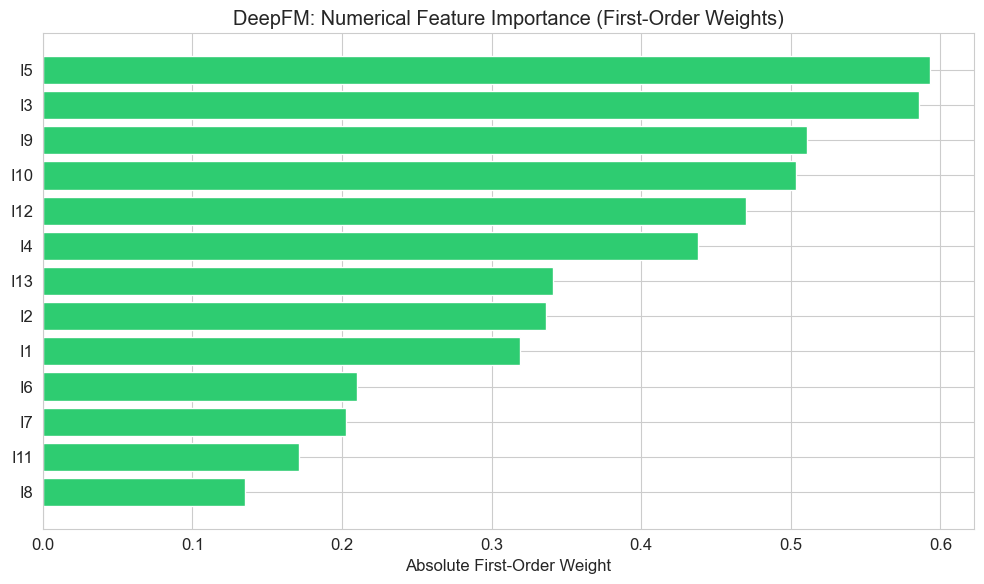

In [8]:
# Extract first-order weights for numerical features
num_weights = model.num_linear.weight.detach().cpu().numpy().flatten()

importance_df = pd.DataFrame({
    'feature': NUM_FEATURES,
    'weight': np.abs(num_weights)
}).sort_values('weight', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['weight'], color='#2ecc71')
ax.set_xlabel('Absolute First-Order Weight')
ax.set_title('DeepFM: Numerical Feature Importance (First-Order Weights)')
plt.tight_layout()
plt.savefig('deepfm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ablation Study

> **Concept:** An ablation study removes individual components from a model to measure
> their contribution. For DeepFM, we compare:
> - **FM-only**: Only first-order + FM second-order (no DNN)
> - **DNN-only**: Only first-order + DNN (no FM second-order)
> - **DeepFM**: Full model (FM + DNN)

> **Note on subsample size:** On small datasets like our 1M subsample, the FM component
> may not improve (or may even hurt) performance compared to the DNN alone. The FM term
> models all pairwise feature interactions, which requires sufficient data density per
> feature pair. With high-cardinality categorical features and limited samples, many
> pairs are underrepresented, leading to noisy interaction estimates. See the Key
> Takeaways section for a detailed analysis.

In [9]:
def train_and_evaluate_model(use_fm, use_dnn, name, num_epochs=10):
    """Train a variant and return best metrics."""
    print(f'\n{"="*60}')
    print(f'Training {name} (FM={use_fm}, DNN={use_dnn})')
    print(f'{"="*60}')
    
    model_variant = DeepFM(
        num_num_features=len(NUM_FEATURES),
        cat_cardinalities=cat_cardinalities,
        embedding_dim=EMBEDDING_DIM,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        use_fm=use_fm,
        use_dnn=use_dnn
    ).to(device)
    
    opt = optim.Adam(model_variant.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    crit = nn.BCEWithLogitsLoss()
    amp_scaler = torch.cuda.amp.GradScaler() if use_amp else None
    
    best_auc_local = 0
    best_logloss_local = 1.0
    
    start = time.time()
    for epoch in range(num_epochs):
        train_loss = train_epoch(model_variant, train_loader, crit, opt, device, amp_scaler)
        _, test_auc, test_logloss = evaluate(model_variant, test_loader, crit, device)
        
        if test_auc > best_auc_local:
            best_auc_local = test_auc
            best_logloss_local = test_logloss
        
        print(f'  Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | '
              f'Test AUC: {test_auc:.4f} | Test LogLoss: {test_logloss:.4f}')
    
    elapsed = time.time() - start
    n_params = sum(p.numel() for p in model_variant.parameters())
    
    return {
        'name': name,
        'auc': best_auc_local,
        'logloss': best_logloss_local,
        'params': n_params,
        'time': elapsed
    }

# Run ablation
ablation_results = []
ablation_results.append(train_and_evaluate_model(use_fm=True, use_dnn=False, name='FM-only'))
ablation_results.append(train_and_evaluate_model(use_fm=False, use_dnn=True, name='DNN-only'))

# Add full DeepFM result
ablation_results.append({
    'name': 'DeepFM',
    'auc': best_auc,
    'logloss': final_logloss,
    'params': total_params,
    'time': total_time
})

ablation_df = pd.DataFrame(ablation_results)
print('\nAblation Results:')
print(ablation_df.to_string(index=False))


Training FM-only (FM=True, DNN=False)


  Epoch  1 | Train Loss: 1.8775 | Test AUC: 0.6950 | Test LogLoss: 0.9177


  Epoch  2 | Train Loss: 0.6974 | Test AUC: 0.7169 | Test LogLoss: 0.6856


  Epoch  3 | Train Loss: 0.5407 | Test AUC: 0.7273 | Test LogLoss: 0.6164


  Epoch  4 | Train Loss: 0.4796 | Test AUC: 0.7349 | Test LogLoss: 0.5862


...

  Epoch  6 | Train Loss: 0.4253 | Test AUC: 0.7794 | Test LogLoss: 0.4735


  Epoch  7 | Train Loss: 0.4177 | Test AUC: 0.7767 | Test LogLoss: 0.4841


  Epoch  8 | Train Loss: 0.4091 | Test AUC: 0.7751 | Test LogLoss: 0.4787


  Epoch  9 | Train Loss: 0.3987 | Test AUC: 0.7668 | Test LogLoss: 0.5028


  Epoch 10 | Train Loss: 0.3874 | Test AUC: 0.7680 | Test LogLoss: 0.5010

Ablation Results:
    name      auc  logloss  params       time
 FM-only 0.745338 0.556960 2161772 340.979311
DNN-only 0.787494 0.460890 2161772 330.611946
  DeepFM 0.755766 0.536916 2161772 320.389471


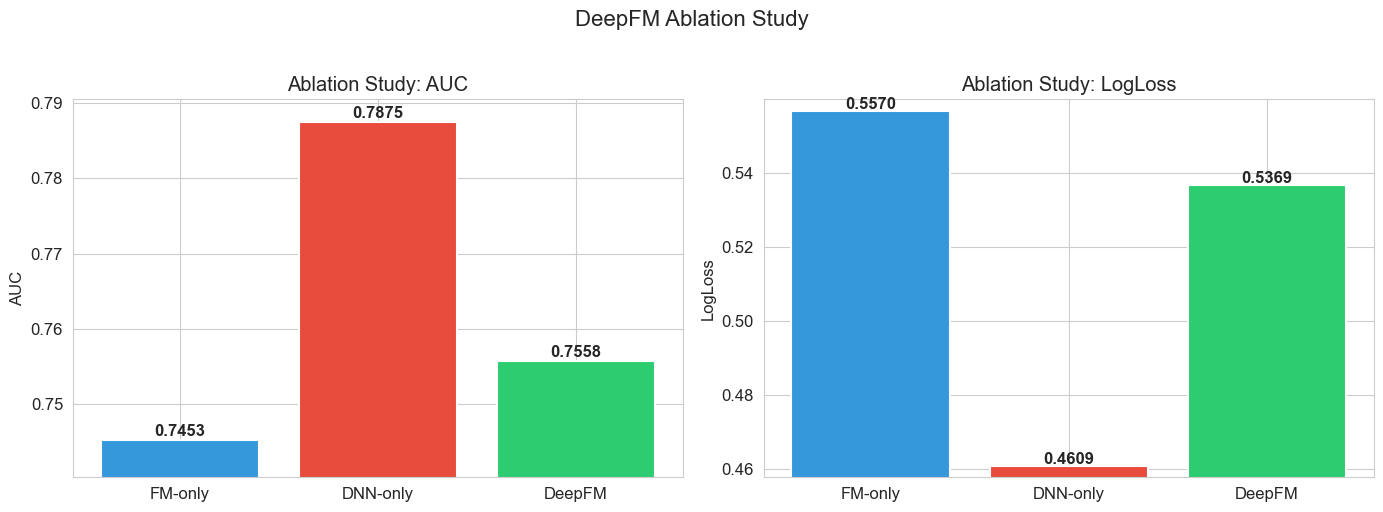

In [10]:
# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71']

# AUC comparison
axes[0].bar(ablation_df['name'], ablation_df['auc'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('AUC')
axes[0].set_title('Ablation Study: AUC')
axes[0].set_ylim(ablation_df['auc'].min() - 0.005, ablation_df['auc'].max() + 0.003)
for i, (_, row) in enumerate(ablation_df.iterrows()):
    axes[0].text(i, row['auc'] + 0.0005, f'{row["auc"]:.4f}', ha='center', fontweight='bold')

# LogLoss comparison
axes[1].bar(ablation_df['name'], ablation_df['logloss'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('LogLoss')
axes[1].set_title('Ablation Study: LogLoss')
axes[1].set_ylim(ablation_df['logloss'].min() - 0.003, ablation_df['logloss'].max() + 0.003)
for i, (_, row) in enumerate(ablation_df.iterrows()):
    axes[1].text(i, row['logloss'] + 0.0005, f'{row["logloss"]:.4f}', ha='center', fontweight='bold')

plt.suptitle('DeepFM Ablation Study', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('deepfm_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Embedding Dimension Sensitivity

How does the embedding dimension affect performance? We test dims = [4, 8, 16, 32].

In [11]:
emb_dims_to_test = [4, 8, 16, 32]
emb_results = []

for edim in emb_dims_to_test:
    print(f'\nTesting embedding_dim={edim}')
    model_emb = DeepFM(
        num_num_features=len(NUM_FEATURES),
        cat_cardinalities=cat_cardinalities,
        embedding_dim=edim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT
    ).to(device)
    
    opt = optim.Adam(model_emb.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    crit = nn.BCEWithLogitsLoss()
    amp_scaler = torch.cuda.amp.GradScaler() if use_amp else None
    
    best_auc_emb = 0
    start = time.time()
    for epoch in range(8):  # Fewer epochs for sensitivity study
        train_epoch(model_emb, train_loader, crit, opt, device, amp_scaler)
        _, test_auc, _ = evaluate(model_emb, test_loader, crit, device)
        best_auc_emb = max(best_auc_emb, test_auc)
        print(f'  Epoch {epoch+1} | AUC: {test_auc:.4f}')
    
    n_params = sum(p.numel() for p in model_emb.parameters())
    emb_results.append({
        'emb_dim': edim,
        'auc': best_auc_emb,
        'params': n_params,
        'time': time.time() - start
    })

emb_df = pd.DataFrame(emb_results)
print('\nEmbedding Dimension Sensitivity:')
print(emb_df.to_string(index=False))


Testing embedding_dim=4


  Epoch 1 | AUC: 0.7241


  Epoch 2 | AUC: 0.7476


  Epoch 3 | AUC: 0.7513


  Epoch 4 | AUC: 0.7490


...

  Epoch 4 | AUC: 0.7554


  Epoch 5 | AUC: 0.7545


  Epoch 6 | AUC: 0.7513


  Epoch 7 | AUC: 0.7523


  Epoch 8 | AUC: 0.7481

Embedding Dimension Sensitivity:
 emb_dim      auc  params       time
       4 0.751297  658676 258.944664
       8 0.758276 1159708 267.049466
      16 0.754739 2161772 276.374353
      32 0.760357 4165900 236.157510


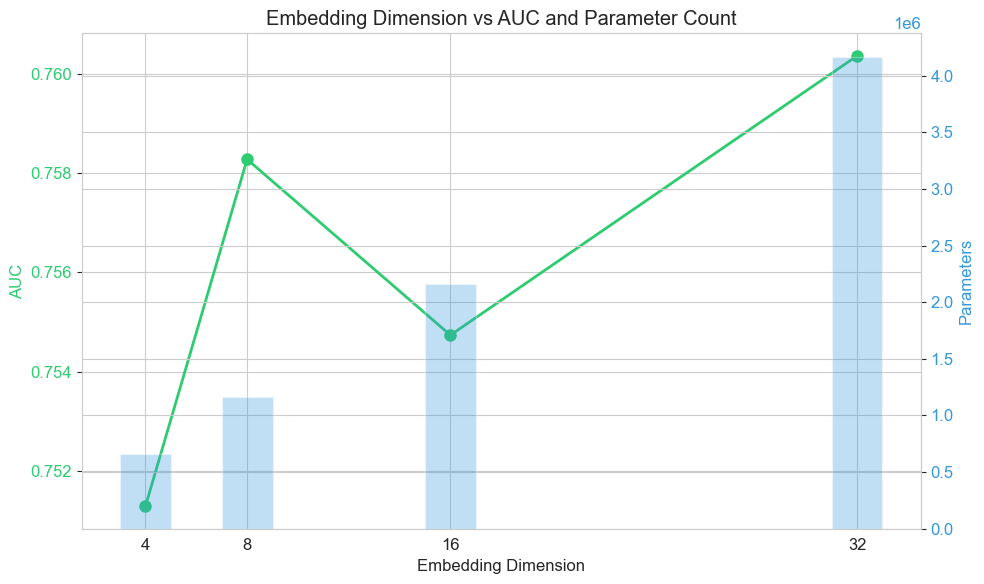

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#2ecc71'
ax1.set_xlabel('Embedding Dimension')
ax1.set_ylabel('AUC', color=color1)
ax1.plot(emb_df['emb_dim'], emb_df['auc'], 'o-', color=color1, linewidth=2, markersize=8, label='AUC')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.set_ylabel('Parameters', color=color2)
ax2.bar(emb_df['emb_dim'], emb_df['params'], alpha=0.3, color=color2, width=2, label='Parameters')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Embedding Dimension vs AUC and Parameter Count')
ax1.set_xticks(emb_dims_to_test)
fig.tight_layout()
plt.savefig('deepfm_emb_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

> **Common Pitfall:** Larger embedding dimensions do not always improve performance.
> Beyond a certain point, the model has too many parameters relative to the training
> data size, leading to overfitting. The embedding dimension should be tuned as a
> hyperparameter.

## 9. Exercises

### Exercise 1: Field-Aware Embedding Dimensions

Instead of using a single `embedding_dim` for all features, implement field-aware embedding dimensions where each feature gets `min(16, max(4, int(log2(cardinality))))`. Compare the performance.

In [13]:
# TODO: Exercise 1
# 1. Modify the DeepFM class to accept per-feature embedding dimensions
# 2. Use the formula: min(16, max(4, int(log2(cardinality)))) for each feature
# 3. Handle the variable-size embeddings in the FM interaction computation
# 4. Train and compare with fixed embedding_dim=16

# Your code here:
pass

### Exercise 2: Dropout Sensitivity

Test dropout values [0.0, 0.1, 0.2, 0.3, 0.5] and plot the results. Which dropout rate gives the best generalization?

In [14]:
# TODO: Exercise 2
# 1. Train DeepFM with different dropout rates
# 2. Record test AUC for each
# 3. Also record the gap between train loss and test loss (overfitting indicator)
# 4. Plot dropout vs AUC and dropout vs train-test gap

# Your code here:
pass

### Exercise 3: Learning Rate Schedule Comparison

Compare three learning rate schedules: (1) constant lr, (2) ReduceLROnPlateau, (3) CosineAnnealingLR. Which converges fastest?

In [15]:
# TODO: Exercise 3
# 1. Train DeepFM with each schedule for 10 epochs
# 2. Plot AUC curves for all three on the same chart
# 3. Discuss convergence speed vs final performance

# Your code here:
pass

### Exercise 4: Visualize Embedding Space

Use t-SNE or PCA to visualize the learned embeddings for a categorical feature (e.g., C1). Do similar categories cluster together?

In [16]:
# TODO: Exercise 4
# 1. Extract the embedding matrix for C1 from the trained model
# 2. Apply t-SNE or PCA to reduce to 2D
# 3. Color points by their average CTR
# 4. Look for clusters of high-CTR and low-CTR categories

# Your code here:
pass

## 10. Summary & Key Takeaways

### Results Summary

In [17]:
print('=' * 60)
print('DeepFM Results Summary')
print('=' * 60)
print(f'Best Test AUC:     {best_auc:.4f}')
print(f'Best Test LogLoss: {final_logloss:.4f}')
print(f'Total Parameters:  {total_params:,}')
print(f'Training Time:     {total_time:.1f}s')
print(f'Device:            {device}')
print('=' * 60)

# Save results for comparison notebook
deepfm_results = {
    'model_name': 'DeepFM',
    'best_auc': best_auc,
    'best_logloss': final_logloss,
    'total_params': total_params,
    'training_time': total_time,
    'history': history,
    'ablation': ablation_df.to_dict(),
    'emb_sensitivity': emb_df.to_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'dropout': DROPOUT,
        'lr': LEARNING_RATE,
        'batch_size': BATCH_SIZE
    }
}

with open(os.path.join(MODEL_DIR, 'deepfm_results.pkl'), 'wb') as f:
    pickle.dump(deepfm_results, f)

print(f'\nResults saved to {MODEL_DIR}/deepfm_results.pkl')

DeepFM Results Summary
Best Test AUC:     0.7558
Best Test LogLoss: 0.5369
Total Parameters:  2,161,772
Training Time:     320.4s
Device:            cpu

Results saved to ./saved_models/deepfm_results.pkl


### Key Takeaways

1. **Shared Embeddings:** DeepFM's key innovation is sharing embeddings between the FM
   and DNN components, eliminating the need for manual feature engineering.

2. **Small-Sample Ablation Insight:** On our 1M subsample, DNN-only (AUC 0.7875)
   outperformed full DeepFM (AUC 0.7558). This is a known phenomenon on smaller datasets:
   - The FM component's second-order interaction term computes pairwise interactions across
     all ~39 feature fields. With only 1M samples and high-cardinality categorical features,
     many feature pairs have sparse co-occurrence, causing the FM term to fit noise rather
     than genuine interaction patterns.
   - The FM and DNN gradients flow through shared embeddings. When the FM component overfits
     on sparse interactions, it can corrupt the embeddings that the DNN relies on, degrading
     overall performance. The high initial training loss (1.41 in epoch 1 for DeepFM vs 0.51
     for DNN-only) suggests the FM term introduces training instability.
   - On the full 45M Criteo dataset, the FM component sees sufficient co-occurrences to learn
     genuine pairwise signals, providing complementary information to the DNN and yielding the
     expected FM+DNN synergy reported in the original paper.
   - **Potential improvement:** Using a lower learning rate for the FM component (e.g., via
     separate parameter groups) or adding L2 regularization specifically to the FM interaction
     term could help stabilize training on small subsamples.

3. **Efficient FM Computation:** The FM second-order interaction can be computed in
   $O(nk)$ time using the sum-of-squares trick, making it scalable.

4. **Embedding Dimension:** There is a sweet spot for embedding dimensions. Too small
   limits expressiveness, too large causes overfitting.

### Next Steps

In the next notebook, we will implement **DCN (Deep & Cross Network)** and **DCN-V2**,
which replace the FM component with explicit cross layers that can model feature
interactions of arbitrary order.